# Netflix Data Visualization

## Objective
Transform the cleaned Netflix dataset into meaningful visual 
stories using Matplotlib and Seaborn.

## Charts Built
1. Pie Chart — Movies vs TV Shows split
2. Horizontal Bar — Top 10 content producing countries
3. Line Chart — Netflix content growth over years
4. Horizontal Bar — Top 10 genres on Netflix
5. Heatmap — Content added by year and type

## Key Insights
- Netflix library is 70% Movies and 30% TV Shows
- USA and India dominate content production
- Netflix grew rapidly between 2016-2019, peaking in 2019
- International Movies and Dramas are the most common genres
- TV Show addition remained consistently lower than Movies

## Libraries Used
- `Matplotlib` — base chart rendering and customization
- `Seaborn` — statistical visualizations with beautiful styling

## Dataset
Netflix Movies and TV Shows — Kaggle (8790 titles)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv", encoding="latin1")
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [3]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")
df = df.dropna()
df['year_added'] = df['date_added'].str.strip().str[-4:]

In [4]:
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 120

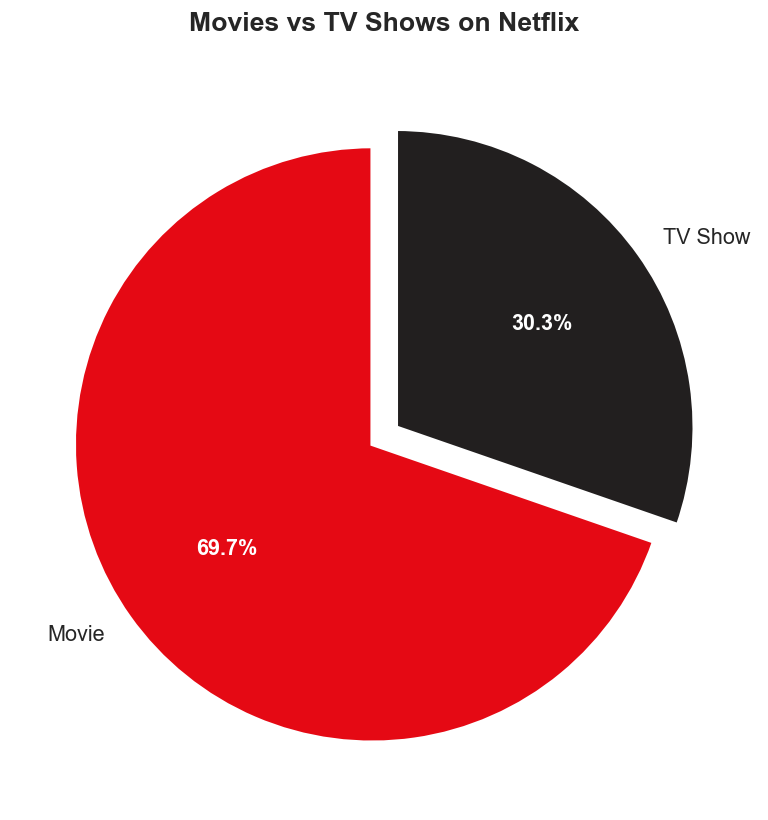

In [5]:
plt.figure(figsize=(7, 7))

type_counts = df['type'].value_counts()
colors = ['#E50914', '#221F1F']
explode = (0.05, 0.05)

patches, texts, autotexts = plt.pie(
    type_counts.values,
    labels=type_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    textprops={'fontsize': 13},
    pctdistance=0.6,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Movies vs TV Shows on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_movies_vs_shows.png', dpi=150)
plt.show()

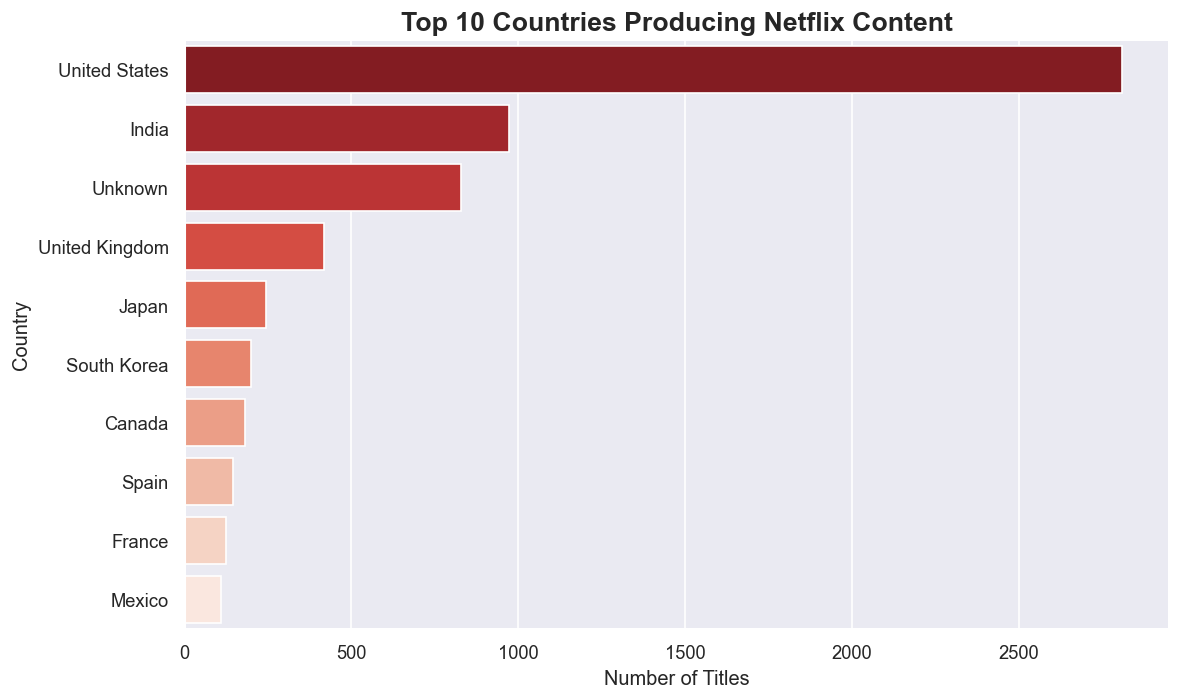

In [35]:
plt.figure(figsize=(10, 6))

top_countries = df['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='Reds_r',
    legend=False
)

plt.title('Top 10 Countries Producing Netflix Content', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.savefig('chart2_top_countries.png', dpi=150)
plt.show()

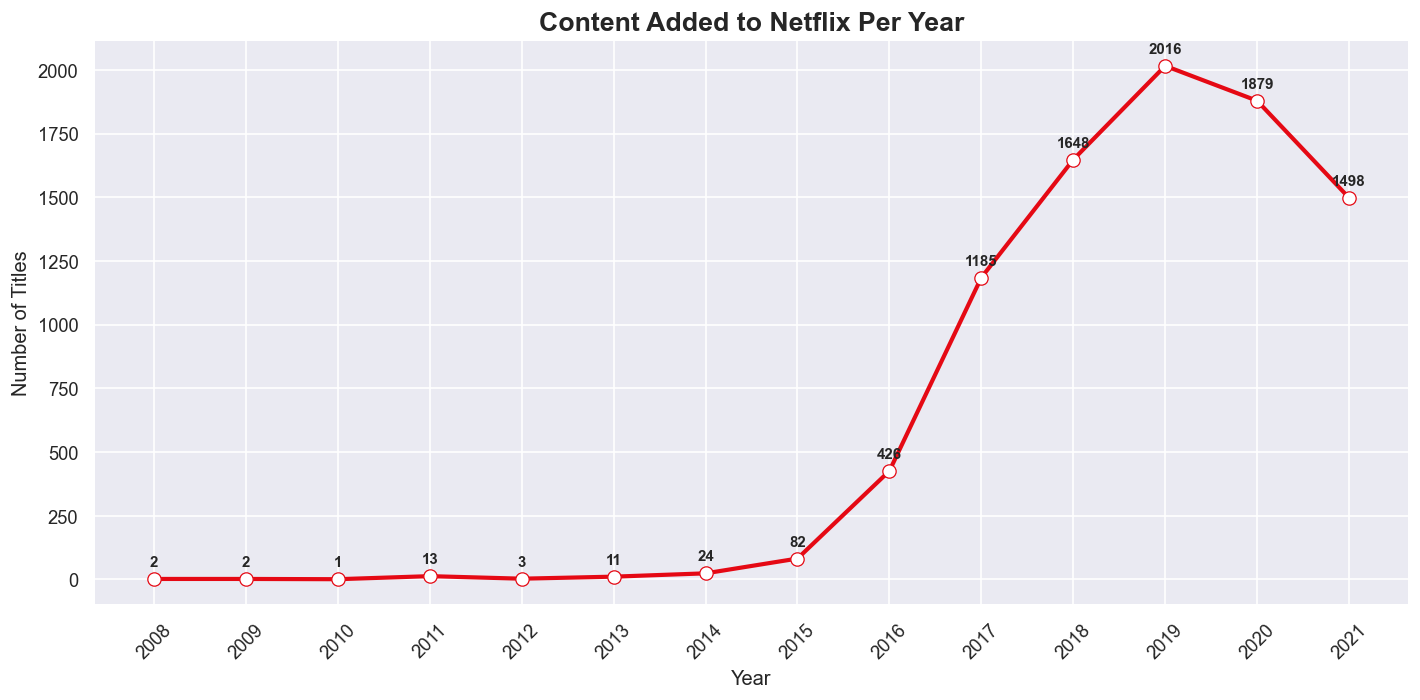

In [28]:
plt.figure(figsize=(12, 6))

year_counts = df['year_added'].value_counts().sort_index()

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o',
    markerfacecolor='white', 
    markeredgecolor='#E50914',      
    color='#E50914',
    linewidth=2.5,
    markersize=8
)

for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y + 50, str(y), ha='center', fontsize=9, fontweight='bold')

plt.title('Content Added to Netflix Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_growth_over_years.png', dpi=150)
plt.show()

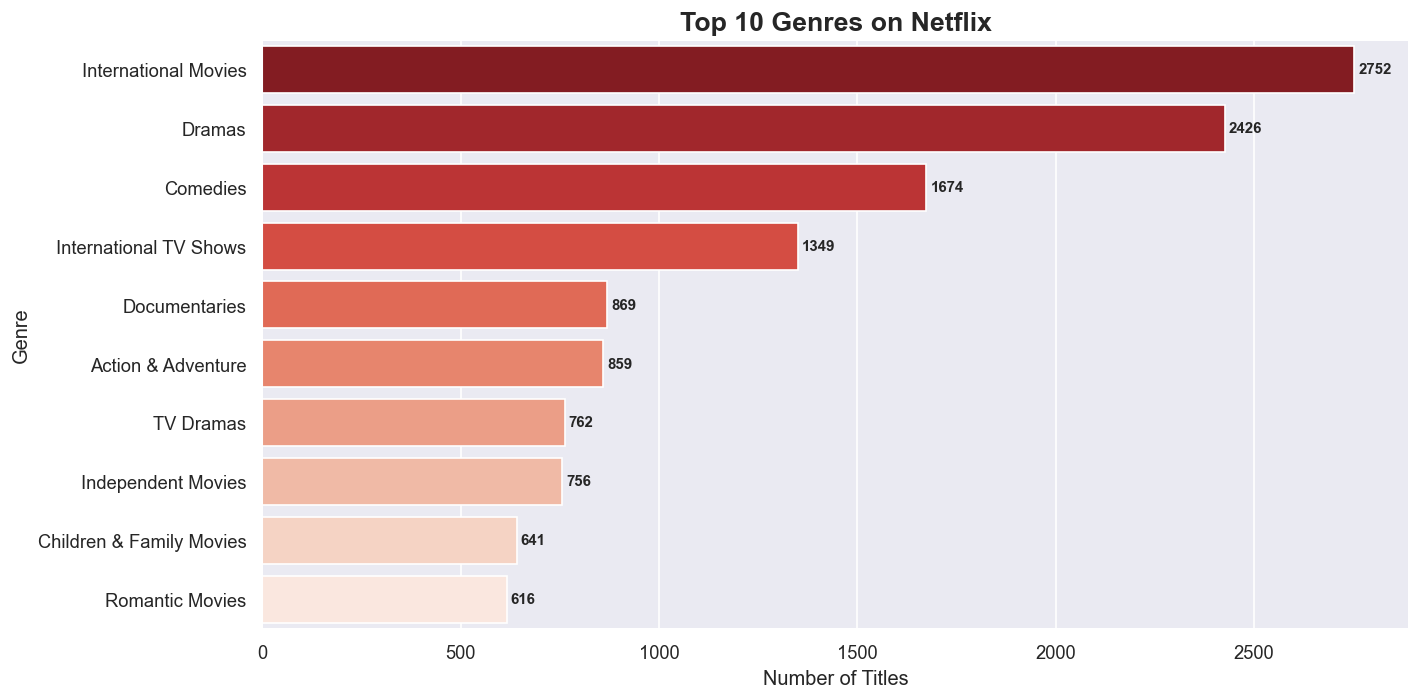

In [ ]:
plt.figure(figsize=(12, 6))

genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    hue=top_genres.index,
    palette='Reds_r',
    legend=False
)

for i, v in enumerate(top_genres.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.savefig('chart4_top_genres.png', dpi=150)
plt.show()

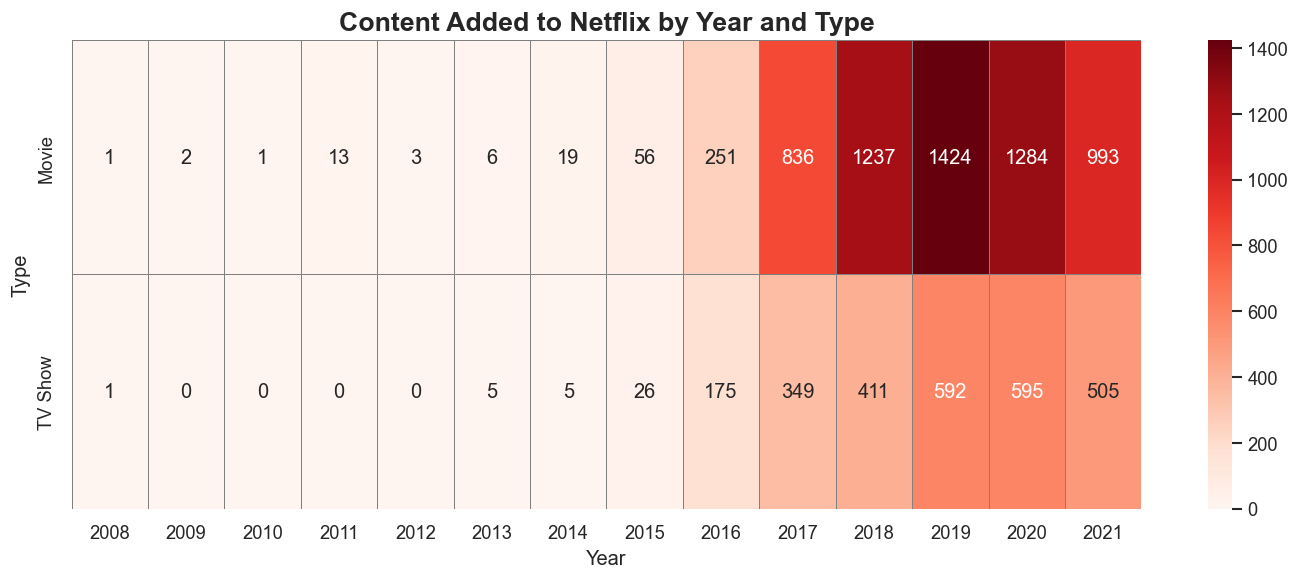

In [ ]:
plt.figure(figsize=(12, 5))

heatmap_data = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

sns.heatmap(
    heatmap_data.T,
    cmap='Reds',
    annot=True,
    fmt='d',
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Content Added to Netflix by Year and Type', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Type', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()